# Design files: Quads design (3dp pla + blue shims) for static cloaking of a smile-shaped void


## Imports

In [1]:
from mechanicalmetamaterialcloaks.utils import load_data
from scripts.fabrication import generate_blocks_continuous_bond_lines_drawing
from problems.quads_static_cloaking import OptimizationProblem
from pathlib import Path

import jax.numpy as jnp

## Paths

In [2]:
# Where to load/save data
data_folder = Path("../../../data/quads_static_cloaking_3dp_pla_shims")


## Problem info

NOTE: Either define the problem info here or load it from an optimization file.

In [3]:
# NOTE: Units are mm, N, s

# Retrieve design info from optimization data
optimization_filename = f"opt_integrated_with_angle_30_and_length_3_constraints_quads_15x15_amplitude_15.0_initial_angle_20.0_void_big_smile"
optimization = OptimizationProblem.from_dict(
    load_data(
        f"{data_folder}/{optimization_filename}.pkl",
    )
)
problem = optimization.forward_problem
# Set up the forward problem to get the geometry
problem.setup()

Setup solver of the intact geometry
Compute dynamics of the intact geometry
Setup solver of the voided geometry
Initialization done


## Sketch with labeled units

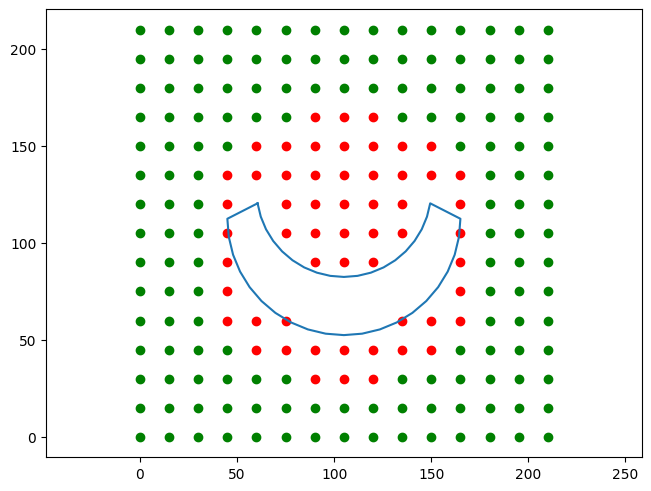

In [8]:
fig, axes = problem.plot_sketch()
out_path = Path(
    f"{data_folder}/{optimization_filename}/svgs/labeled_units.svg"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path)

## Drawings reference geometry

In [11]:
# Retrieve geometry
geometry = problem.mother_geometry
# Select design variables
design_values = problem.horizontal_vertical_shifts_mg

generate_blocks_continuous_bond_lines_drawing(
    block_centroids=geometry.block_centroids(*design_values),
    centroid_node_vectors=geometry.centroid_node_vectors(*design_values),
    bond_connectivity=geometry.bond_connectivity(),
    reference_bond_vectors=geometry.reference_bond_vectors(),
    n1_blocks=geometry.n1_blocks,
    n2_blocks=geometry.n2_blocks,
    offset_type="constant",  # ["ratio", "constant"]
    offset_size=3, # mm
    path_orientation="column",
    out_file=f"{data_folder}/{optimization_filename}/svgs/reference_geometry.svg",
)


Design size is 222.75x222.75 mm
Saved at ../../../data/quads_static_cloaking_3dp_pla_shims/opt_integrated_with_angle_30_and_length_3_constraints_quads_15x15_amplitude_15.0_initial_angle_20.0_void_big_smile/svgs/reference_geometry.svg


## Drawings inclusion geometry

In [31]:
# Retrieve geometry
geometry = problem.mother_geometry
# Select design variables
design_values = optimization.design_values[0]

generate_blocks_continuous_bond_lines_drawing(
    block_centroids=geometry.block_centroids(*problem.cloak_to_all_shifts(design_values)),
    centroid_node_vectors=geometry.centroid_node_vectors(*problem.cloak_to_all_shifts(design_values)),
    bond_connectivity=geometry.bond_connectivity(),
    reference_bond_vectors=geometry.reference_bond_vectors(),
    n1_blocks=problem.n1_blocks,
    n2_blocks=problem.n2_blocks,
    offset_type="constant",  # ["ratio", "constant"]
    offset_size=3, # mm
    path_orientation="column",
    out_file=f"{data_folder}/{optimization_filename}/svgs/inclusion_geometry.svg",
)


Design size is 222.75x222.75 mm
Saved at ../../../data/quads_static_cloaking_3dp_pla_shims/opt_integrated_with_angle_30_and_length_3_constraints_quads_15x15_amplitude_15.0_initial_angle_20.0_void_big_smile/svgs/inclusion_geometry.svg


## Drawings cloak geometry

In [17]:
# Retrieve geometry
geometry = problem.mother_geometry
# Select design variables
design_values = optimization.design_values[-1]

generate_blocks_continuous_bond_lines_drawing(
    block_centroids=geometry.block_centroids(*problem.cloak_to_all_shifts(design_values)),
    centroid_node_vectors=geometry.centroid_node_vectors(*problem.cloak_to_all_shifts(design_values)),
    bond_connectivity=geometry.bond_connectivity(),
    reference_bond_vectors=geometry.reference_bond_vectors(),
    n1_blocks=problem.n1_blocks,
    n2_blocks=problem.n2_blocks,
    offset_type="constant",  # ["ratio", "constant"]
    offset_size=3, # mm
    path_orientation="column",
    out_file=f"{data_folder}/{optimization_filename}/svgs/cloaked_geometry.svg",
)


Design size is 222.75x222.75 mm
Saved at ../../../data/quads_static_cloaking_3dp_pla_shims/opt_integrated_with_angle_30_and_length_3_constraints_quads_15x15_amplitude_15.0_initial_angle_20.0_void_big_smile/svgs/cloaked_geometry.svg
